# Focus main effect

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency
from statsmodels.stats.contingency_tables import Table

import seaborn as sns

## Combined Subgroup:

1. Contigency Table
2. Proportions
3. Chi-Square Test
4. Expected Counts
5. Cramér's V
6. Standardized Residuals
7. Interpretation

Read data

In [2]:
subgroup_theoretical = pd.read_csv("../../data/processed/subgroup_theoretical.csv")

In [3]:
subgroup_theoretical= subgroup_theoretical[subgroup_theoretical["Response_Full"]!= "missing_response"].copy()

1. Contingency Table

In [4]:
contingency = pd.crosstab(
    subgroup_theoretical["Focus"],
    subgroup_theoretical["Response_Full"]
)

contingency

Response_Full,L1_transfer,L2_other,correct
Focus,,,
I,53,24,40
They,43,14,21


"I" produces more correct responses and more L2_other responses. 
"They", produces proportionally more transfer responses. 

2. Proportions

In [5]:
proportions = pd.crosstab(
    subgroup_theoretical["Focus"],
    subgroup_theoretical["Response_Full"],
    normalize="index"
)

proportions

Response_Full,L1_transfer,L2_other,correct
Focus,,,
I,0.452991,0.205128,0.341880
They,0.551282,0.179487,0.269231


Focus doesn't simply change "correcteness"; it changes where responses go.

3. Chi-Square Test

In [6]:
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square: {chi2:.3f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")

Chi-square: 1.866
p-value: 0.3934
Degrees of freedom: 2


There is no evidence of association. Overall, Focus alone does not produce a statistically detectable change. 

4. Expected Counts

In [7]:
expected_df = pd.DataFrame(
    expected,
    index=contingency.index,
    columns=contingency.columns
)

expected_df

Response_Full,L1_transfer,L2_other,correct
Focus,,,
I,57.6,22.8,36.6
They,38.4,15.2,24.4


In [8]:
print(expected_df < 5)

Response_Full  L1_transfer  L2_other  correct
Focus                                        
I                    False     False    False
They                 False     False    False


From the original responses, there are no groups with fewer than 5 observations. 

5. Cramér's V

In [9]:
n = contingency.values.sum()

cramers_v = np.sqrt(
    chi2 / (n * (min(contingency.shape) - 1))
)

print(f"Cramér's V: {cramers_v:.3f}")

Cramér's V: 0.098


V = 0.098 : the effect size is tiny.

6. Standardized Residuals

In [10]:
residuals = (
    contingency - expected
) / np.sqrt(expected)

residuals

Response_Full,L1_transfer,L2_other,correct
Focus,,,
I,-0.606103,0.251312,0.562003
They,0.742322,-0.307794,-0.688310


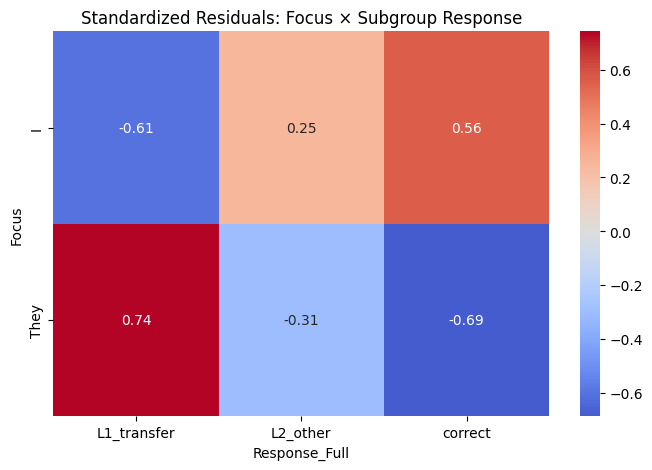

In [11]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    residuals,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Standardized Residuals: Focus × Subgroup Response")
plt.show()

7. Interpretation

Nothing exceeds +-2; so, no cell drives the chi-sq but the direction does stand out:

- When Focus = I, there is less transfer and more correct responses.
- When Focus = They, there is more transfer and less correct responses.

Therefore, the effect isn't significant but the direction is internally consistent

## Goal Behaviour Subgroup:
### Goals

1. Contigency Table
2. Proportions
3. Chi-Square Test
4. Expected Counts
5. Cramér's V
6. Standardized Residuals
7. Interpretation

Split data into goals vs. no_goals

In [12]:
goals = subgroup_theoretical[subgroup_theoretical["Goal_Type"]!= "no_goal"].copy()

In [13]:
no_goals = subgroup_theoretical[subgroup_theoretical["Goal_Type"]== "no_goal"].copy()

1. Contigency Table

In [14]:
goal_contingency = pd.crosstab(
    goals["Focus"],
    goals["Response_Full"]
)

goal_contingency

Response_Full,L1_transfer,L2_other,correct
Focus,,,
I,31,19,29
They,31,7,14


2. Proportions

In [15]:
goal_proportions = pd.crosstab(
    goals["Focus"],
    goals["Response_Full"],
    normalize="index"
)

goal_proportions

Response_Full,L1_transfer,L2_other,correct
Focus,,,
I,0.392405,0.240506,0.367089
They,0.596154,0.134615,0.269231


Proportions become sharper: compared to combined data, transfer decreases and correct rises when focus = I, when Focus = They, then transfer increases and correct stays much lower

3. Chi-Square Test 

In [16]:
chi2, p, dof, expected = chi2_contingency(goal_contingency)

print(f"Chi-square: {chi2:.3f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")

Chi-square: 5.437
p-value: 0.0660
Degrees of freedom: 2


Just by spliting data and targeting goals (goal_frequent and goal_non_frequent), chi-sq shows over double the effect size. Removing the no_goal observations didn't reduce the information but concentrated it. 

4. Expected Counts

In [17]:
goal_expected_df = pd.DataFrame(
    expected,
    index=goal_contingency.index,
    columns=goal_contingency.columns
)

goal_expected_df

Response_Full,L1_transfer,L2_other,correct
Focus,,,
I,37.389313,15.679389,25.931298
They,24.610687,10.320611,17.068702


In [18]:
print(goal_expected_df < 5)

Response_Full  L1_transfer  L2_other  correct
Focus                                        
I                    False     False    False
They                 False     False    False


5. Cramér's V

In [19]:
n = goal_contingency.values.sum()

cramers_v = np.sqrt(
    chi2 / (n * (min(goal_contingency.shape) - 1))
)

print(f"Cramér's V: {cramers_v:.3f}")

Cramér's V: 0.204


V = 0.204 vs. V = 0.098; this is more than twice as large and same direction.

6. Standardized Residuals

In [20]:
goal_residuals = (
    goal_contingency - expected
) / np.sqrt(expected)

goal_residuals

Response_Full,L1_transfer,L2_other,correct
Focus,,,
I,-1.044914,0.838597,0.602619
They,1.287930,-1.033630,-0.742770


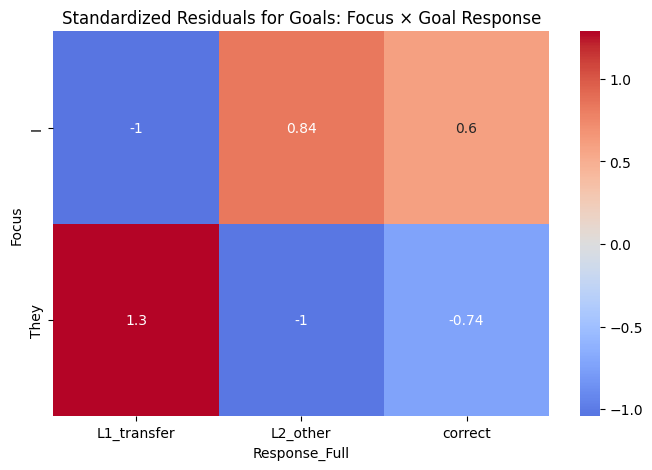

In [21]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    goal_residuals,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Standardized Residuals for Goals: Focus × Goal Response")
plt.show()

7. Interpretation

Nothing exceeds +-2 yet; so, no cell drives the chi-sq but the direction now is even clearer:

- When Focus = I, there is less transfer and more correct responses, which has increased a little bit.
- When Focus = They, transfer has almost doubled and still fewer correct responses.

Nothing has changed direction.

## Goal Behaviour Subgroup:
### No Goals

1. Contigency Table
2. Proportions
3. Chi-Square Test
4. Expected Counts
5. Cramér's V
6. Standardized Residuals
7. Interpretation

1. Contigency Table

In [22]:
no_goal_contingency = pd.crosstab(
    no_goals["Focus"],
    no_goals["Response_Full"]
)

no_goal_contingency

Response_Full,L1_transfer,L2_other,correct
Focus,,,
I,22,5,11
They,12,7,7


2. Proportions

In [23]:
no_goal_proportions = pd.crosstab(
    no_goals["Focus"],
    no_goals["Response_Full"],
    normalize="index"
)

no_goal_proportions

Response_Full,L1_transfer,L2_other,correct
Focus,,,
I,0.578947,0.131579,0.289474
They,0.461538,0.269231,0.269231


Focus clearly separated the 2 response strategies for goal observations; for no goals, the pattern changes and the biggest change is in the L2-other alternatives: I = 13% and they = 27%, almost doubles. 

3. Chi-Square Test

In [24]:
chi2, p, dof, expected = chi2_contingency(no_goal_contingency)

print(f"Chi-square: {chi2:.3f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")

Chi-square: 1.983
p-value: 0.3710
Degrees of freedom: 2


As expected, no evidence of association. 

4. Expected Counts

In [25]:
no_goal_expected_df = pd.DataFrame(
    expected,
    index=no_goal_contingency.index,
    columns=no_goal_contingency.columns
)

no_goal_expected_df

Response_Full,L1_transfer,L2_other,correct
Focus,,,
I,20.1875,7.125,10.6875
They,13.8125,4.875,7.3125


In [26]:
print(no_goal_expected_df < 5)

Response_Full  L1_transfer  L2_other  correct
Focus                                        
I                    False     False    False
They                 False      True    False


5. Cramér's V

In [27]:

n = no_goal_contingency.values.sum()

cramers_v = np.sqrt(
    chi2 / (n * (min(no_goal_contingency.shape) - 1))
)

print(f"Cramér's V: {cramers_v:.3f}")

Cramér's V: 0.176


Despite chi-sq results, V = 0.176 is actually saying something. It isn't as high as goal's V (0.204) but it isn't that far either. There seems to be structure here but a different one.

6. Standardized Residuals

In [28]:
no_goal_residuals = (
    no_goal_contingency - expected
) / np.sqrt(expected)

no_goal_residuals

Response_Full,L1_transfer,L2_other,correct
Focus,,,
I,0.403401,-0.796098,0.095590
They,-0.487688,0.962435,-0.115563


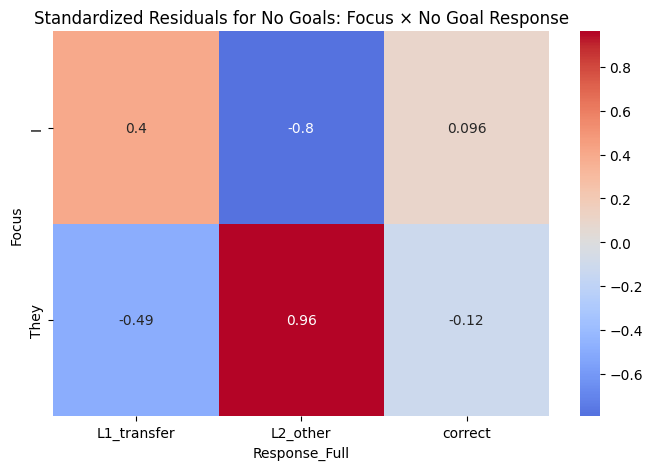

In [29]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    no_goal_residuals,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Standardized Residuals for No Goals: Focus × No Goal Response")
plt.show()

7. Interpretation

- Residuals clearly show what proportions already said. No cells are driving the association but it is clear that, compared to goals, this shows that no goals follow a different mechanism. The largest residual was They x transfer for goals (1.29); the largest residual for no goals is They x L2_other (0.96)